# LEARNING OBJECTIVE

This notebook illustrates how judicious use of dimensional analysis, in conjuction with a bit of data, can very nearly solve a complex fluid dynamics problem. Specifically, the example of G. I. Taylor and the yield of the first atomic bomb test is featured.

# PRELIMINARIES

[run the next cell to setup Python environment customizations and load packages]

In [1]:
# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# ploting customizations
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# numerics
import numpy as np
from scipy.integrate import trapezoid

# for Colab only: you need to install scipy-dae
#!pip install scipy-dae
from scipy_dae.integrate import solve_dae

# for Colab only: to save plots as files and download them
#from google.colab import files


## Credit

Initial version written by [Tanmay C. Shidhore](https://scholar.google.com/citations?user=gKD-U0AAAAAJ) with further contributions by Shrihari D. Pande and [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

# PROBLEM STATEMENT

_G.I. Taylor and the Trinity Test_

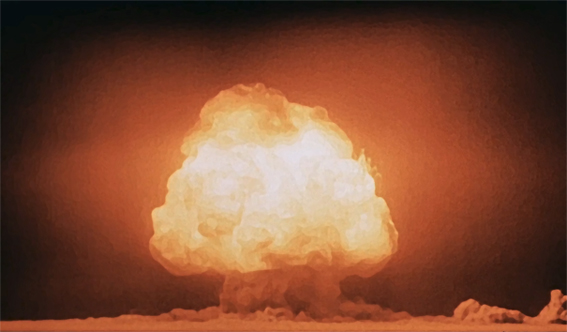

"[Mushroom cloud of 'Gadget' over Trinity, seconds after detonation](https://commons.wikimedia.org/wiki/File:Trinity_Detonation_T%26B.jpg)" courtesy of the US Department of Energy.


The [Trinity Test](https://www.atomicheritage.org/history/trinity-test-1945) in 1945 was the culmination of the Manhattan Project and the first ever atomic bomb explosion. As the story goes, famous Cambridge fluid dynamicist [G.I. Taylor](https://en.wikipedia.org/wiki/G._I._Taylor) estimated its energetic yield (a closely guarded and classified secret at the time) from time-lapse photographs he saw in the newspaper. (Of course, as such stories often go, there is a [bit of exaggeration](https://www-tandfonline-com.ezproxy.lib.purdue.edu/doi/full/10.1080/0020739X.2011.562324).) We wish to reproduce some of G.I.'s analysis using the knowledge gained from ME 50900. Specifically:

(a) Using dimensional analysis, determine a dimensionless form of the relationship: $E$, the energy released by the explosion, as a function of
1.   $R$, the radius of the fireball,
2.   $t$, the time since detonation,
3.   $p$, the pressure inside the fireball,
4.   $p_0$, the pressure outside the fireball (that is, atmospheric pressure),
5.   $\rho$, the density of heated air inside the fireball, and
6.   $\rho_0$, the density of air outside the fireball.

(b) Simplify your dimensionless relationship obtained in (a) by assuming that (_i_) the density of the superheated air in the fireball $\rho$, compared to the density of ordinary air $\rho_0$, is negligible; (_ii_) the atmospheric pressure $p_0$, compared to the pressure inside the exploding fireball $p$, is negligible; and (_iii_) the energy $E$ released by the atomic blast is much greater than any energy scale involving "ordinary" quantities like $p_0$, $\rho_0$ and $t$.

Applying these assumptions to the result in (a), deduce a direct scaling relation (no unknown function, just a proportionality constant) between $E$, $\rho_0$, $R$, and $t$.

(c) The fireball spreads in a self-similar way such that $R^5t^{-2}=const.$ To confirm this statement, we can use publicly available [photographs](https://www.atomicheritage.org/history/trinity-test-1945) at the time. Digitize some of this data yourself (or use Table 1 in G.I.'s [2nd paper](https://royalsocietypublishing.org/doi/abs/10.1098/rspa.1950.0050) but, note that G.I.'s Eq. (2) has a typo: "$\times 10^2$" should clearly be "$\times 10^{2\mathbf{3}}$".) and plot $R$ versus $t$ on a log-log plot. Show that $R^5t^{-2}=const.$ is a line on this log-log plot and goes through the data. From this plot, and/or a simple data fit, estimate the numerical value of this constant (don't forget its units), which corresponds to the "$y$-intercept value" of the linear fit on the log-log plot.

(d) Finally, using the results from (b) and (c), and assuming the proportionality constant from the dimensional analysis in (b) is "very nearly 1" (this is not an obvious assumption, and G.I. justified it using the compressible flow equations), as well as $\rho_0 = 1.225$ kg/m$^3$ at standard atmosphere, estimate the energetic yield $E$.

How close to the reported (from the [Report on the Trinity Test by General Groves](https://www.atomicarchive.com/resources/documents/trinity/groves.html)) of 15 to 20 [kilotons of TNT](https://en.wikipedia.org/wiki/TNT_equivalent) did you get?

# SOLUTION

## (a)

We seek how $E$ depends on $R$, $t$, $p$, $p_0$, $\rho$, $\rho_0$ ($1+6=7$ parameters).

The primary dimensions are, as usual, $\mathsf{M}, \mathsf{L}$ and $\mathsf{T}$.

Dimensional matrix is
$$
\begin{array}{c|c|c|c|c|c|c|c}
& E & R & t & p & p_0 & \rho & \rho_0\\
\hline
\mathsf{M} & 1  & 0   & 0   & 1    & 1    & 1  & 1\\
\hline
\mathsf{L} & 2  & 1   & 0   & -1   & -1   & -3 & -3\\
\hline
\mathsf{T} &-2  & 0   & 1   & -2   & -2   & 0  & 0
\end{array}
,
$$
and we can calculate its rank and nullspace basis vectors:

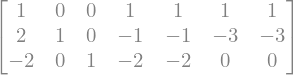

In [2]:
DimMat = sp.Matrix([[1, 0, 0, 1, 1, 1, 1], [2, 1, 0, -1, -1, -3, -3], [-2, 0, 1, -2, -2, 0, 0]])
DimMat

In [3]:
DimMat.rank()

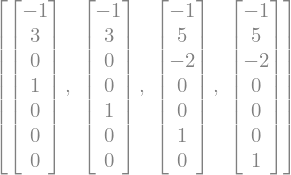

In [4]:
NullDimMat = DimMat.nullspace()
NullDimMat

The nullspace of the dimensional matrix is $4$-dimensional, so we expect $4$ $\Pi$ groups to show up in the problem.

Without putting any thought into it, we transcribe the nullspace basis vectors into $\Pi$ groups:
\begin{align*}
    \Pi_1 &= \frac{R^3 p}{E}, \\
    \Pi_2 &= \frac{R^3 p_0}{E}. \\
    \Pi_3 &= \frac{R^5 \rho}{E t^2}, \\
    \Pi_4 &= \frac{R^5 \rho_0}{E t^2}.
\end{align*}

Notice $E$ shows up in several groups, this is bad news for trying express it as $E(R,t,\dots)$ in an explicity way. So, we'll do some re-arranging next.

## (b)

In anticipation of the given assumptions, we do a few manipulations, which we are allowed to do because $\Pi$ groups are not unique.

To enable assumptions (_i_) and (_ii_), we redefine
\begin{align*}
  \tilde{\Pi}_1 = \frac{\Pi_2}{\Pi_1} = \frac{p_0}{p} \ll 1,\\
  \tilde{\Pi}_3 = \frac{\Pi_4}{\Pi_3} = \frac{\rho}{\rho_0} \ll 1.
\end{align*}

To get the energy and the "ordinary" quantities $p_0$, $\rho_0$ and $t$ involved, we seek to eliminate $R$ from one of the remaining un-redefined groups:
$$
\tilde{\Pi}_2 = \frac{\Pi_2}{\Pi_4^{3/5}} = \frac{p_0}{E^{-2/5}} \frac{t^{6/5}}{\rho_0^{3/5}}
$$
and to make it nicer,
$$
  \tilde{\tilde{\Pi}}_2 = \tilde{\Pi}_2^{-5/2} = \frac{E \rho^{3/2}}{p_0^{5/2} t^3} = \frac{E}{p_0^{5/2} t^3/\rho_0^{3/2}} \ll 1.
$$
And,
$$
  \tilde{\Pi}_4 = \frac{1}{\Pi_4}
$$
to get $E$ in the numerator.

Now, the functional form of the original relationship was:
$$
  E(R, t, p, p_0, \rho, \rho_0).
$$
By Buckingham's $\Pi$-theorem and the analysis above, it can be also written as:
$$
  \tilde{\Pi}_4(\tilde{\Pi}_1, \tilde{\tilde{\Pi}}_3, \tilde{\Pi}_2)
$$
or
$$
  \frac{E t^2}{R^5 \rho_0} \left(\frac{p_0}{p}, \frac{\rho}{\rho_0}, \frac{E}{p_0^{5/2} t^3/\rho_0^{3/2}} \right).
$$

Using assumptions (_i_)-(_iii_), we neglect the dependence upon the $\tilde{\Pi}_1$, $\tilde{\Pi_2}$, $\tilde{\tilde{\Pi}}_3$ (equivalently, evaluate the function at the point at which all 3 equal 0), so we seek:
$$
\frac{E t^2}{R^5 \rho_0} (0, 0, 0).
$$
The value of $\frac{E t^2}{R^5 \rho_0}$ as a function of "stuff" when "stuff" $=(0,0,0)$ is, in principle, just some number. G. I. claims this number is "very nearly 1":
$$
\frac{E t^2}{R^5 \rho_0} \approx 1.
$$

## (c)

The theory (dimensional analysis) suggests that $R^5t^{-2}=const.$ We would like to verify this from the actual explosion observations, and determine $const.$ if we can.

Rather than digitizing photographs themselves, we take the data for $R(t)$ summarized in Table 1 in G.I.'s [2nd paper](https://royalsocietypublishing.org/doi/abs/10.1098/rspa.1950.0050).

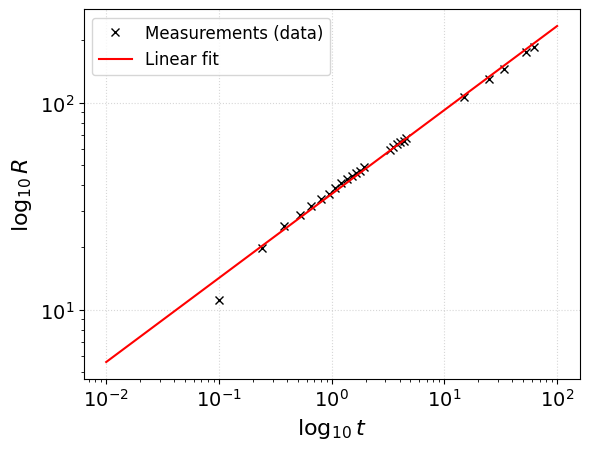

In [5]:
# Time t (in msec)
t =  np.array([0.1,0.24,0.38,0.52,0.66,0.8,0.94,1.08,1.22,1.36,1.5,1.65,\
               1.79,1.93,3.26,3.53,3.8,4.07,4.34,4.61,15,25,34,53,62])

# Blast wave radius R (in m)
R =  np.array([11.1,19.9,25.4,28.8,31.9,34.2,36.3,38.9,41,42.8,44.4,46,\
               46.9,48.7,59,61.1,62.9,64.3,65.6,67.3,106.5,130,145,175,185])

# Fit a polynomial of order 1 (i.e., a line) to R(t) in the log-log plane
m, b = np.polyfit(np.log10(t),np.log10(R),1)

# Evaluate and report on the fit
t_fit = np.logspace(-2,2,100,base=10.0)
R_fit = (10.0**b)*(t_fit**m)

# Make a plot of the data and the fit
plt.loglog(t,R,'kx',label='Measurements (data)')
plt.loglog(t_fit,R_fit,color='r',label='Linear fit')
plt.xlabel(r'$\log_{10}t$')
plt.ylabel(r'$\log_{10}R$')
plt.grid(alpha=0.5, linestyle='dotted')
plt.legend()
plt.show()

In [6]:
print(f'Slope of data fit in log-log plot (in appropriate units): {m:.6f}')
print(f'Intercept of fata fit in log-log plot (in appropriate units): {b:.6f}')

Slope of data fit in log-log plot (in appropriate units): 0.405823
Intercept of fata fit in log-log plot (in appropriate units): 1.559268


From the above data analysis, we learn that (abusing units a bit since $R$ is in meters but we took its $\log_{10}$ . . .):
$$ \log_{10}R \approx 0.405823  \log_{10}t + 1.559268. $$

Note that the fitted slope of $0.41$ is close to the value expected from the dimensional analysis scaling law, i.e., $2/5=0.4$, obtained from
$$ \log_{10} (R^{5}t^{-2}) = \log_{10} const. \quad\Rightarrow\quad \log_{10} R = \frac{2}{5} \log_{10} t + \frac{1}{5}\log_{10}const. $$

The value of the constant may be determined as (taking into account a unit conversion):
$$ \frac{1}{5}\log_{10}const. \approx 1.559268 \quad\Rightarrow\quad const. = 10^{5\cdot 1.559268} \times \frac{1}{10^{-6}} \,\,\mathrm{m}^5 \mathrm{s}^{-2}, $$
so:

In [7]:
constant = 10**(5*b)/(1e-6)
print(f'{constant:.6e}') # convert to scientific notation

6.256648e+13


## (d)

From part (a) and the givens, we expect that
$$\frac{E \, t^2}{R^5 \rho_0} \approx 1.$$

Hence, the blast energy can be estimated as:
$$E \approx (R^5 t^{-2})\rho_0.$$

We found that $R^5 t^{-2}\approx const.$ too and the value of the constant was determined in part (c). Plugging that into the expression, along with $\rho_0 = 1.225$ kg/m$^3$ gives the energetic content of the explosion, $E$, in Joules. This value may be converted into kilotons of TNT by dividing it by $4.184\times 10^{12}$, yielding:

In [8]:
E = (constant*1.225)/(4.184e12)
print(f'{E:.6f}')

18.318340


# THE CONSTANT THAT'S "VERY NEARLY 1"

The title of this section, refers to the interesting historical discussion in Sec. 9 of [Deakin's paper](https://www-tandfonline-com.ezproxy.lib.purdue.edu/doi/full/10.1080/0020739X.2011.562324).

For the purposes of our discussion/assignment, I'd like to explore whether the right-hand side of the expression,
$$\frac{E \, t^2}{R^5 \rho_0} \approx 1,$$
from (d) is indeed "very nearly 1" as assumed.

## Governing equations and self-similar transformation

The experimental data analyzed shows that the radius of the blast wave goes as
$$
  R(t) = S(\gamma) t^{2/5} E^{1/5} \rho_0^{-1/5},
$$
which we recognize is the expression from (d) rearranged, and $S(\gamma)$ was found in (c) to be $\approx 6.26 \times 10^{13}$ m<sup>5</sup>/s<sup>2</sup>.

G. I. exploited this idea in his [1st paper](https://royalsocietypublishing.org/doi/10.1098/rspa.1950.0049) as intuition to seek a self-similar solution of the gas dynamics equations (possibly discussed in ME 51000). Specifically, he defined a self-similarity variable as
$$
  \eta=\frac{r}{R(t)},
$$
so that $\eta = 1$ corresponds to $r=R(t)$, the dynamic radial extent of the fireball, which at this stage is **unknown**. Based on the image data, he anticipated that $R(t) \sim t^{2/5}$ should come up in the self-similar analysis, but this dependence could only be verified by actually doing the self-similar transformation.


G. I. started with the spherically-symmetric [Euler equations](https://en.wikipedia.org/wiki/Euler_equations_(fluid_dynamics)) of an inviscid compressible fluid:
\begin{align*}
  \frac{\partial \rho}{\partial t}+u\frac{\partial \rho}{\partial r} + \rho\left(\frac{\partial u}{\partial r} + \frac{2u}{r} \right) &= 0,\\
  \frac{\partial u}{\partial t}+u\frac{\partial u}{\partial r} &= - \frac{1}{\rho}\frac{\partial p}{\partial r},\\
  p\rho^{-\gamma} &= const.,
\end{align*}
where the first one is the continuity equation, the second is the $r$-momentum equation, and the third is the equation of state (ideal gas). Here, $\gamma$ is the so-called [_adiabatic index_](https://en.wikipedia.org/wiki/Heat_capacity_ratio), the ratio of specific heats of a compressible fluid. It is thermodynamic constant. G. I. took the material derivative of the last equation to get rid of the "_const._" as:
$$
  \left(\frac{\partial}{\partial t} + u\frac{\partial}{\partial r}\right)(p\rho^{-\gamma}) = 0.
$$

To determine a possible self-similar solution, G. I. introduced the following transformation:
\begin{align*}
\frac{\rho(r,t)}{\rho_0} &= \psi(\eta),\\
R^3\frac{a^2}{A^2}\frac{p(r,t)}{p_0} &= f(\eta),\\
R^{3/2}\frac{1}{A} u(r,t) &= \phi(\eta),
\end{align*}
where the self-similarity variable is
$$
\eta=\frac{r}{R(t)},
$$
and $a$ is the [adiabatic speed of sound in air](https://en.wikipedia.org/wiki/Speed_of_sound#Speed_of_sound_in_ideal_gases_and_air) defined based on the ambient conditions as $a=\sqrt{\gamma p_0/\rho_0}$.

Substituting the self-similar transformation into the spherically-symmetric Euler equations above, G. I. was successful in reducing the problem to 3 ODEs:
\begin{align*}
  \frac{1}{\gamma\psi} f'- (\eta-\phi)\phi' &= \frac{3}{2}\phi,\\
  \psi' - \frac{\psi}{\eta-\phi} \phi' &= \frac{2\phi\psi}{\eta(\eta-\phi)},\\
   (\phi-\eta)f' - \frac{\gamma}{\psi}(\phi-\eta) f\psi' &= 3f,
\end{align*}
**only if**
$$
  \frac{dR}{dt} = A R^{-3/2}
$$
holds, which is consistent with the data and intituion above (!) but $A$ is to be determined from scratch in this analysis. The primes denoted $\eta$ derivatives as usual.

The ODEs for $\psi$, $f$, and $\phi$ are subject to the boundary conditions
\begin{align*}
  \psi(1) = \frac{\gamma + 1}{\gamma - 1},\\
  f(1) = \frac{2\gamma}{\gamma + 1},\\
  \phi(1) = \frac{2}{\gamma + 1},
\end{align*}
which G. I. derived from the normal shock relations at the edge of the fireball.

## Numerical solution

Unfortunately, the ODEs G. I. obtained are known as [differential-algebraic equations (DAEs)](https://en.wikipedia.org/wiki/Differential-algebraic_system_of_equations) because derivatives of several of the dependent variables are mixed together on the LHS for each equation (and, worse, with nonconstant coefficients).

This system of ODEs cannot be resolved in the form $(\psi',f',\phi') = \vec{F}(\psi,f,\phi)$, which would be required to use SciPy's `solve_ivp`.

We try a rather challenging approach using DAE solvers from J. Breuling's [`scipy_dae`](https://github.com/JonasBreuling/scipy_dae) implementation.

The ODEs above are posed subject to a BC at $\eta=1$, which can also be called a _final condition_. This means they are to be integrated backwards from $\eta=1$ to $\eta=0$. This is awkward.

To integrate from $0$ to $1$, which is more typical, we let $\eta=1-\eta^{*}$. Then, the ODEs become a proper initial value problem:
\begin{align*}
  -\frac{1}{\gamma\psi}f' + ((1-\eta^{*})-\phi)\phi' - \frac{3}{2}\phi &= 0,\\
  -\psi'+\frac{\psi}{(1-\eta^{*})-\phi}\phi' - \frac{2\phi\psi}{(1-\eta^{*})((1-\eta^*)-\phi)} &=0 ,\\
  -(\phi-(1-\eta^{*}))f' + \frac{\gamma}{\psi}(\phi-(1-\eta^{*}))f\psi' - 3f &=0.
\end{align*}
Written this way, as $\vec{F}(\eta^*,\psi,f,\phi,\psi',f',\phi')=\vec{0}$, the problem can be coded up for solution using the DAE solver.

In [ ]:
# the 'state' vector y = [psi, f, phi]
# the 'derivative' vector is yp = [psi', f', phi']
# gamma is passed as the parameter g
# es is \eta*
def residual(es,y,yp,g):
  res_0 = -1/(g*y[0])*yp[1] + ((1-es) - y[2])*yp[2] - 1.5*y[2]
  res_1 = -yp[0] + y[0]/((1-es) - y[2])*yp[2] - 2*y[0]*y[2]/((1-es)*((1-es)-y[2]))
  res_2 = -(y[2]-(1-es))*yp[1] + g/y[0]*(y[2]-(1-es))*y[1]*yp[0] - 3*y[1]

  return np.array([res_0,res_1,res_2])

The initial conditions are now
\begin{align*}
  \psi(0) &= \frac{\gamma + 1}{\gamma - 1},\\
  f(0) &= \frac{2\gamma}{\gamma + 1},\\
  \phi(0) &= \frac{2}{\gamma + 1}.
\end{align*}
However, we also need expressions for the derivatives at $\eta^*=0$ for the numerical method. G. I. somehow anticipated this, and he provided the following formulas:
\begin{align*}
  \psi'(0) &= -\left[\frac{\phi'(0) + 2\phi(0)}{1 - \phi(0)}\right] \psi(0),\\
  f'(0) &= -\left[\frac{(n+2)\alpha\gamma^2}{\gamma - 1 - \gamma\alpha}\right]f(0),\\
  \phi'(0) &= -\left(\frac{1}{\gamma} + \alpha n\right),
\end{align*}
where
\begin{align*}
  \alpha = \frac{\gamma - 1}{\gamma(\gamma + 1)},\\
  n = \frac{7\gamma - 1}{\gamma^2 - 1}.
\end{align*}

In [ ]:
# value of adiabatic index
g = 1.4

# initial conditions
es0 = 0
y0  = [(g+1)/(g-1), 2*g/(g+1), 2/(g+1)]
alpha = (g-1)/(g*(g+1))
n = (7*g-1)/(g**2-1)
yp0 = [-((-1/g+alpha*n + 2*y0[2])/(1 - y0[2])*y0[0]),
       -(2*g**2+7*g-3)/(g-1),
       -(1/g+alpha*n)]

In [15]:
# eta^* span for solving and plotting
es1 = 0.99
es_span = (es0, es1)
es_eval = np.linspace(0, 0.99, num=100)

# solver options
method = "Radau" # Radau is most robust for this problem
# method = "BDF" # alternative solver
atol = rtol = 1e-10

# solve DAE system
sol = solve_dae(lambda es, y, yp: residual(es, y,yp,g),
                es_span, y0, yp0, atol=atol, rtol=rtol, 
                method=method, t_eval=es_eval)
es = sol.t
y = sol.y

# remap back to original domain and grab solutions
eta = np.ones_like(es) - es
psi = y[0]
f = y[1]
phi = y[2]

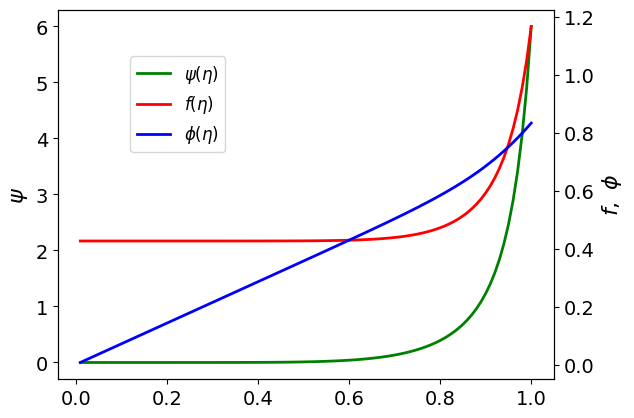

In [16]:
# Make a plot of the data and the fit
fig, ax1 = plt.subplots()

ax1.plot(eta,psi,label=r'$\psi(\eta)$',lw=2,color='green')
ax1.set_ylabel(r'$\psi$')

ax2 = ax1.twinx()
ax2.plot(eta,f,label=r'$f(\eta)$',lw=2,color='red')
ax2.plot(eta,phi,label=r'$\phi(\eta)$',lw=2,color='blue')

ax2.set_ylabel(r'$f,~\phi$')
ax2.set_xlabel(r'$\eta$')

fig.legend(bbox_to_anchor=(0.4,0.8));
#fig.show()

## Final remarks

G. I. showed the energy of the fireball can be computed from teh self-similar solution as
\begin{align*}
  E &= \overbrace{4\pi\int_0^R \frac{1}{2}\rho u^2 r^2 dr}^{\text{kinetic energy}} + \overbrace{4\pi\int_0^R \frac{p}{\gamma-1} r^2 dr}^{\text{heat energy}}\\
    &= 4\pi A^2 \Big[ \frac{1}{2}\rho_0
    \underbrace{\int_0^1 \psi(\eta) \phi^2(\eta) \, \eta^2 d\eta}_{=I_1} + \frac{p_0}{a^2(\gamma-1)} \underbrace{\int_0^1 f(\eta) \, \eta^2 d\eta}_{I_2} \Big],
\end{align*}
where we recall that $a^2 = \gamma p_0/\rho_0$.

We can evaluate the integrals numerically from the numerical solution for $\psi$, $f$, and $\phi$ using the [`trapezoid`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.trapezoid.html) rule from SciPy's `integrate`.

In [13]:
# remember that psi, f, phi are functions
# of eta* = es so we integrate w.r.t. to es
I1 = trapezoid(psi*(phi**2)*eta**2, es)
I2 = trapezoid(f*eta**2, es)

In his self-similar analysis, G. I. determined that $dR/dt=A R^{-3/2}$ was a necessarity condition for redution of the PDEs to ODEs. Solving this ODE for $R(t)$ subject to $R(0)=0$ (the blast wave was a point source), we have $R(t) = (5/2)^{2/5}A^{2/5}t^{2/5}$ or $A^2 = \frac{4}{25}R^5t^{-2}$. This is the assertion also supported by the data, but now $A$ is not found from fitting, instead it is found from the self-similarity analysis.

Thus,
$$ E = K \rho_0 R^5t^{-2},\qquad K =4\pi \frac{4}{25} \Big[ \frac{1}{2} I_1 + \frac{1}{\gamma(\gamma-1)} I_2 \Big] $$

In [14]:
K = 4*np.pi*4/25*(I1/2 + I2/g/(g-1))
print(f'{K:.6f}')

0.852476


OK, so $0.85$ is not quite 1 but maybe it's ok to call it "very nearly 1" so
$$ \frac{E t^{2}}{\rho_0 R^5} = 0.85... \approx 1.$$